In [126]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [127]:
# Load dataset
df = pd.read_csv("ai 2020.csv")

# Show first 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [128]:
df.shape

(10000, 14)

In [ ]:
df.columns 

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df["Machine failure"].value_counts()


In [129]:
df["Machine failure"].value_counts(normalize=True) * 100 

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [131]:
df_drop = df.drop(columns=[
    "UDI", 
    "Product ID",
    "TWF", 
    "HDF", 
    "PWF", 
    "OSF", 
    "RNF"
])

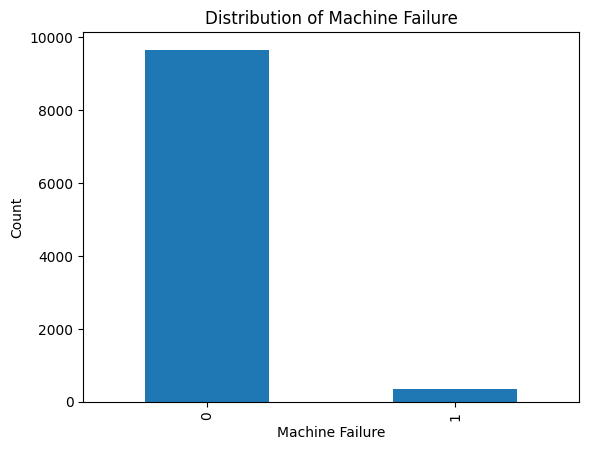

In [132]:
df["Machine failure"].value_counts().plot(kind="bar")
plt.title("Distribution of Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

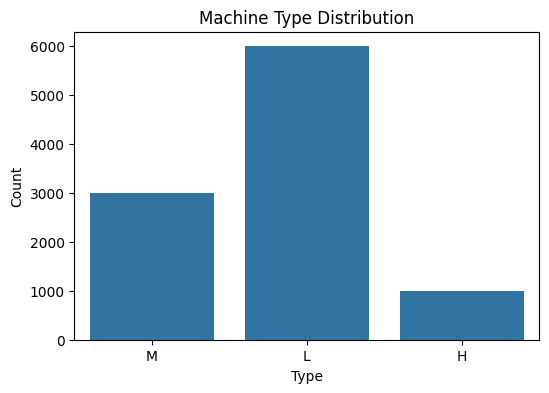

In [133]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Type")
plt.title("Machine Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

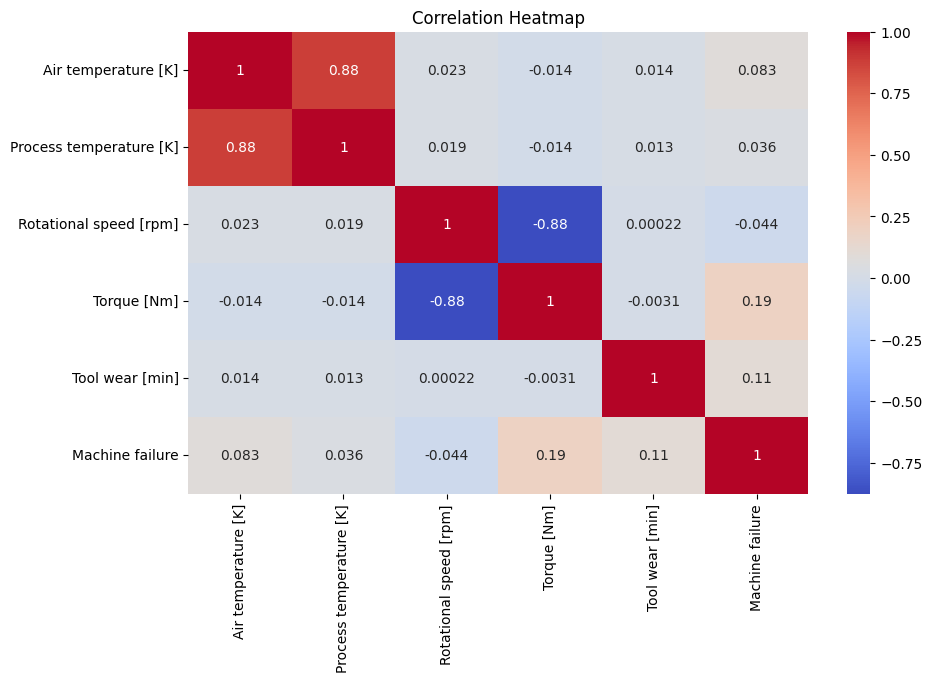

In [134]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_drop.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

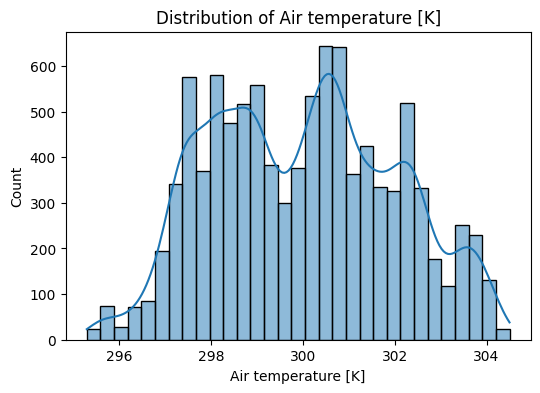

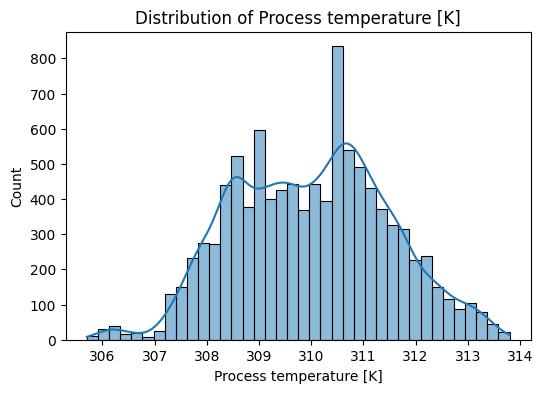

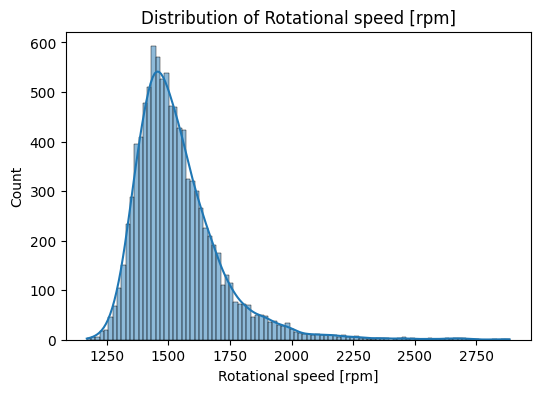

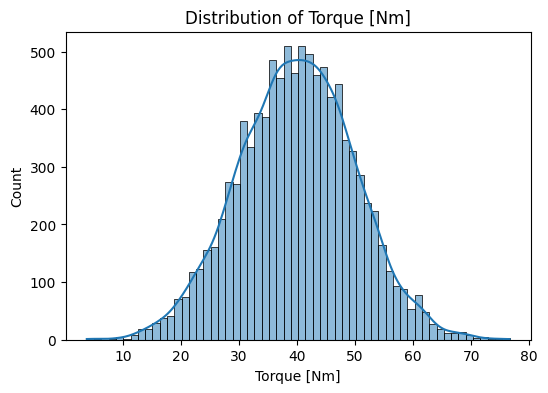

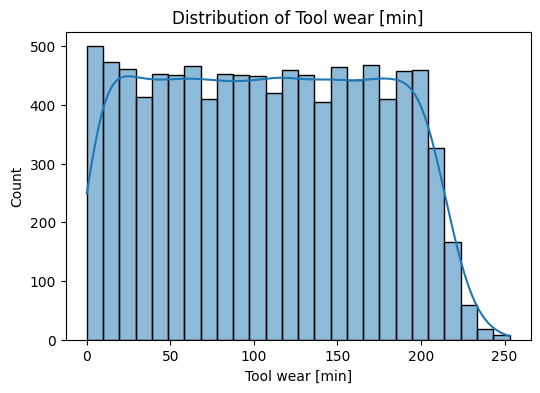

In [135]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

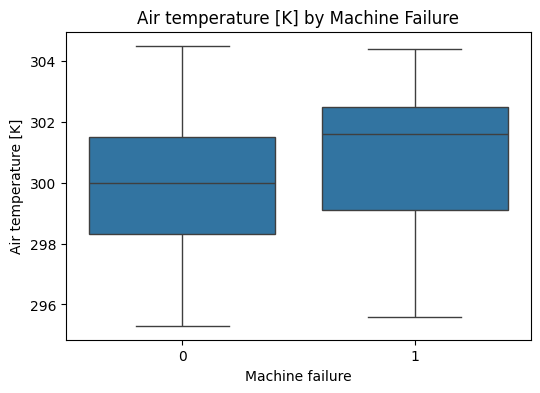

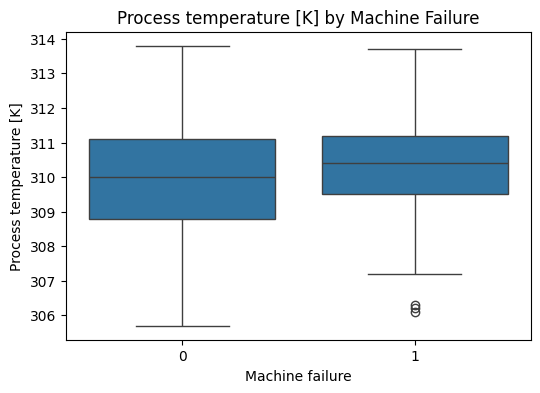

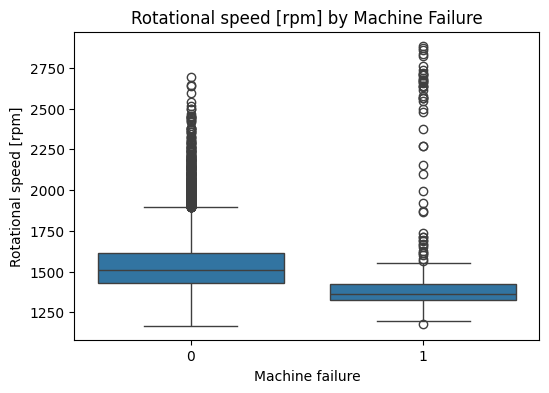

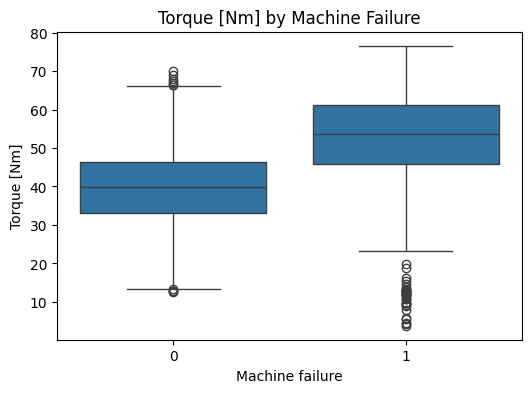

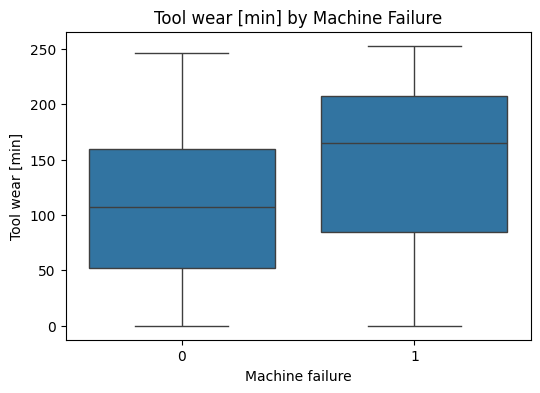

In [136]:
for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Machine failure", y=col)
    plt.title(f"{col} by Machine Failure")
    plt.show()

In [137]:
X = df_drop.drop(columns=["Machine failure"])
y = df_drop["Machine failure"]

In [138]:
encoder = OneHotEncoder(sparse_output=False)

# Encode the Type column
encoded_type = encoder.fit_transform(X[["Type"]])

# Convert encoded values into a DataFrame
encoded_type_df = pd.DataFrame(
    encoded_type,
    columns=encoder.get_feature_names_out(["Type"]),
    index=X.index
)

# Drop the original categorical column
X = X.drop("Type", axis=1)

# Add the encoded columns back to X
X = pd.concat([X, encoded_type_df], axis=1)

# Display prepared features
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0.0,0.0,1.0
1,298.2,308.7,1408,46.3,3,0.0,1.0,0.0
2,298.1,308.5,1498,49.4,5,0.0,1.0,0.0
3,298.2,308.6,1433,39.5,7,0.0,1.0,0.0
4,298.2,308.7,1408,40.0,9,0.0,1.0,0.0


In [139]:
# Split the data into training and temporary sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split the temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Display the shapes of each dataset
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (7000, 8)
Validation set: (1500, 8)
Test set: (1500, 8)


In [140]:
# Create scaler
scaler = MinMaxScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [141]:
log_model = LogisticRegression(solver='liblinear')

log_model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Logistic Regression - Validation Results
Validation Accuracy: 0.966

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1449
           1       0.00      0.00      0.00        51

    accuracy                           0.97      1500
   macro avg       0.48      0.50      0.49      1500
weighted avg       0.93      0.97      0.95      1500


Confusion Matrix:
[[1449    0]
 [  51    0]]


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

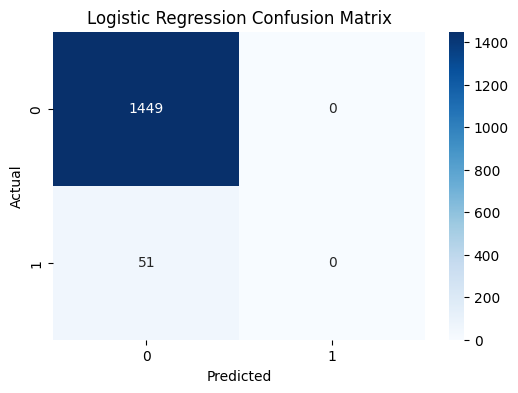

In [142]:
log_val_predictions = log_model.predict(X_val_scaled)

# Calculate validation accuracy
log_val_accuracy = accuracy_score(y_val, log_val_predictions)

print("Logistic Regression - Validation Results")
print("Validation Accuracy:", log_val_accuracy)

print("\nClassification Report:")
print(classification_report(y_val, log_val_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, log_val_predictions))

# Create confusion matrix
log_cm = confusion_matrix(y_val, log_val_predictions)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(log_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [148]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
forest_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Make predictions on the validation data
forest_val_predictions = forest_model.predict(X_val_scaled)

# Calculate validation accuracy
forest_val_accuracy = accuracy_score(y_val, forest_val_predictions)

Random Forest - Validation Results
Validation Accuracy: 0.9766666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1449
           1       0.79      0.43      0.56        51

    accuracy                           0.98      1500
   macro avg       0.88      0.71      0.77      1500
weighted avg       0.97      0.98      0.97      1500


Confusion Matrix:
[[1443    6]
 [  29   22]]


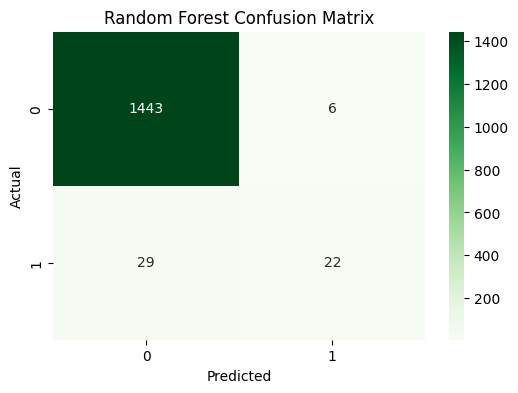

In [145]:
print("Random Forest - Validation Results")
print("Validation Accuracy:", forest_val_accuracy)

print("\nClassification Report:")
print(classification_report(y_val, forest_val_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, forest_val_predictions))

# Create confusion matrix
forest_cm = confusion_matrix(y_val, forest_val_predictions)

# Plot confusion matrix using a different colour
plt.figure(figsize=(6, 4))
sns.heatmap(forest_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [146]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Validation Accuracy": [
        log_val_accuracy,
        forest_val_accuracy
    ]
})

# Display comparison table
comparison

,Model,Validation Accuracy
0,Logistic Regression,0.966000
1,Random Forest,0.976667


In [147]:
# Sort models by validation accuracy
comparison_sorted = comparison.sort_values(
    by="Validation Accuracy",
    ascending=False
)

# Display best model
best_model_name = comparison_sorted.iloc[0]["Model"]
best_model_accuracy = comparison_sorted.iloc[0]["Validation Accuracy"]

print("Best model:", best_model_name)
print("Best validation accuracy:", best_model_accuracy)

Best model: Random Forest
Best validation accuracy: 0.9766666666666667


In [159]:
forest_model_optimised = RandomForestClassifier(
    n_estimators=150,
    max_depth= None ,
    min_samples_split= 2,
    random_state=42
)
# Train the optimised Random Forest model
forest_model_optimised.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Optimised Random Forest - Validation Results
Validation Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1449
           1       0.82      0.53      0.64        51

    accuracy                           0.98      1500
   macro avg       0.90      0.76      0.82      1500
weighted avg       0.98      0.98      0.98      1500


Confusion Matrix:
[[1443    6]
 [  24   27]]


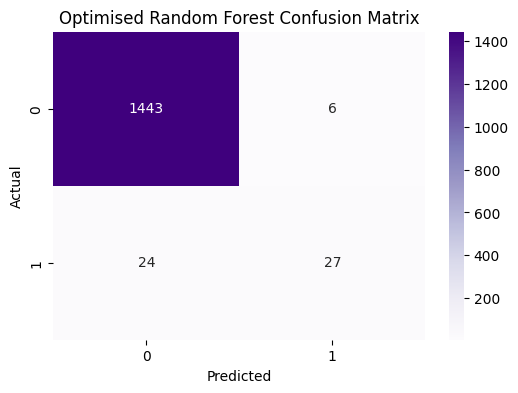

In [160]:
# Make predictions on the validation data
forest_optimised_val_predictions = forest_model_optimised.predict(X_val_scaled)

# Calculate validation accuracy
forest_optimised_val_accuracy = accuracy_score(y_val, forest_optimised_val_predictions)

print("Optimised Random Forest - Validation Results")
print("Validation Accuracy:", forest_optimised_val_accuracy)

print("\nClassification Report:")
print(classification_report(y_val, forest_optimised_val_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, forest_optimised_val_predictions))

# Create confusion matrix
forest_optimised_cm = confusion_matrix(y_val, forest_optimised_val_predictions)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(forest_optimised_cm, annot=True, fmt="d", cmap="Purples")
plt.title("Optimised Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Create model comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Optimised Random Forest"
    ],
    "Validation Accuracy": [
        log_val_accuracy,
        forest_val_accuracy,
        forest_optimised_val_accuracy
    ]
})
comparison

,Model,Validation Accuracy
0,Logistic Regression,0.966000
1,Random Forest,0.976667
2,Optimised Random Forest,0.980000
